# CNN evaluation HDF5 demo

This notebook evaluates CNN prediction files generated by:

```bash
python cbc_pe/scripts/train_cnn_hdf5.py --config <config.json>
```

The current goal is to compare candidate CNN architectures trained on the 100k HDF5 dataset using the 80/20 train/validation split.

This notebook focuses on:

- global validation metrics
- per-label validation metrics
- standardized-space metrics
- physical-space metrics
- absolute-error quantiles
- detailed diagnostics for a selected model

In [ ]:
from pathlib import Path
import os
import sys
import json

import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd()

# Allow running either from repository root or from cbc_pe/.
if PROJECT_ROOT.name != "cbc_pe" and (PROJECT_ROOT / "cbc_pe").exists():
    PROJECT_ROOT = PROJECT_ROOT / "cbc_pe"

os.chdir(PROJECT_ROOT)

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

# Main data root for CIEMAT/local office workflow.
DATA_ROOT = Path("/scratch/vserrano/cbc_pe_data")

DATA_PROCESSED = DATA_ROOT / "processed"
DATA_RESULTS = DATA_ROOT / "results"
DATA_MODELS = DATA_ROOT / "models"

dataset_id = "bbh_processed_4s_seobnrv4opt_snr10-25_n100_000"
MODEL_RESULTS_DIR = DATA_RESULTS / dataset_id

print("PROJECT_ROOT:", PROJECT_ROOT)
print("DATA_ROOT:", DATA_ROOT)
print("DATA_PROCESSED:", DATA_PROCESSED)
print("MODEL_RESULTS_DIR:", MODEL_RESULTS_DIR)
print("MODEL_RESULTS_DIR exists:", MODEL_RESULTS_DIR.exists())

## Register models to compare

Add one entry per trained model.

When a new model finishes training, add its prediction file to `prediction_files` and re-run the comparison cells.

In [ ]:
prediction_files = {
    "M00_baseline_emb64_seed123": MODEL_RESULTS_DIR / (
        "bbh_processed_4s_seobnrv4opt_snr10-25_n100_000"
        "_SimpleCNN_Baseline_M00_simple_emb64_mse_MSELoss_seed123"
        "_train_val_predictions_embeddings.npz"
    ),
    "M00_baseline_emb64_seed124": MODEL_RESULTS_DIR / (
        "bbh_processed_4s_seobnrv4opt_snr10-25_n100_000"
        "_SimpleCNN_Baseline_M00_simple_emb64_mse_MSELoss_seed124"
        "_train_val_predictions_embeddings.npz"
    ),
    "M00_baseline_emb64_seed125": MODEL_RESULTS_DIR / (
        "bbh_processed_4s_seobnrv4opt_snr10-25_n100_000"
        "_SimpleCNN_Baseline_M00_simple_emb64_mse_MSELoss_seed125"
        "_train_val_predictions_embeddings.npz"
    ),
    "M01_pool1_emb128": MODEL_RESULTS_DIR / (
        "bbh_processed_4s_seobnrv4opt_snr10-25_n100_000"
        "_SimpleCNN_Pool_M01_emb128_pool1_MSELoss_seed123"
        "_train_val_predictions_embeddings.npz"
    ),
    "M02_pool4_emb128": MODEL_RESULTS_DIR / (
        "bbh_processed_4s_seobnrv4opt_snr10-25_n100_000"
        "_SimpleCNN_Pool_M02_emb128_pool4_MSELoss_seed123"
        "_train_val_predictions_embeddings.npz"
    ),
    "M04_pooldeep_emb128_pool4": MODEL_RESULTS_DIR / (
        "bbh_processed_4s_seobnrv4opt_snr10-25_n100_000"
        "_SimpleCNN_PoolDeep_M04_emb128_pool4_deephead_MSELoss_seed123"
        "_train_val_predictions_embeddings.npz"
    ),
    "M04_pooldeep_emb128_pool4_drop_wd": MODEL_RESULTS_DIR / (
        "bbh_processed_4s_seobnrv4opt_snr10-25_n100_000"
        "_SimpleCNN_PoolDeep_M04_emb128_pool4_deephead_dropout020_wd1e3_MSELoss_seed123"
        "_train_val_predictions_embeddings.npz"
    ),
    "M06_WideCNN_emb128_pool4": MODEL_RESULTS_DIR / (
        "bbh_processed_4s_seobnrv4opt_snr10-25_n100_000"
        "_WideCNN_Pool_M06_emb128_pool4_widecnn_MSELoss_seed123"
        "_train_val_predictions_embeddings.npz"
    ),
}



for model_id, path in prediction_files.items():
    print(f"{model_id:30s} exists={path.exists()}  file={path.name}")

## Metric helper functions

In [ ]:
def regression_metrics(y_true, y_pred):
    residual = y_true - y_pred

    mse = np.mean(residual**2, axis=0)
    rmse = np.sqrt(mse)
    mae = np.mean(np.abs(residual), axis=0)
    bias = np.mean(residual, axis=0)
    residual_std = np.std(residual, axis=0)

    ss_res = np.sum(residual**2, axis=0)
    ss_tot = np.sum((y_true - np.mean(y_true, axis=0))**2, axis=0)
    r2 = 1.0 - ss_res / ss_tot

    global_mse = np.mean(residual**2)
    global_rmse = np.sqrt(global_mse)
    global_mae = np.mean(np.abs(residual))

    return {
        "mse": mse,
        "rmse": rmse,
        "mae": mae,
        "bias": bias,
        "residual_std": residual_std,
        "r2": r2,
        "global_mse": global_mse,
        "global_rmse": global_rmse,
        "global_mae": global_mae,
    }


def abs_error_quantiles(y_true, y_pred, label_names, model_id, space):
    abs_err = np.abs(y_true - y_pred)
    rows = []

    for j, label in enumerate(label_names):
        q50, q90, q95, q99 = np.quantile(abs_err[:, j], [0.50, 0.90, 0.95, 0.99])

        rows.append({
            "model_id": model_id,
            "space": space,
            "label": label,
            "q50_abs_error": q50,
            "q90_abs_error": q90,
            "q95_abs_error": q95,
            "q99_abs_error": q99,
            "max_abs_error": abs_err[:, j].max(),
        })

    return rows


def get_label_names(data):
    if "label_names" in data.files:
        return [str(x) for x in data["label_names"].tolist()]
    return ["chirp_mass", "total_mass", "chi_eff"]


def load_history_npz(history_path):
    history_path = Path(history_path)

    if not history_path.exists():
        return None

    with np.load(history_path, allow_pickle=True) as data:
        files = list(data.files)

        if "train_loss" in files and "val_loss" in files:
            arrays = {
                key: data[key]
                for key in files
                if np.asarray(data[key]).ndim <= 1
            }
            history_df = pd.DataFrame(arrays)

        elif "history" in files:
            obj = data["history"].tolist()

            if isinstance(obj, dict):
                history_df = pd.DataFrame(obj)
            elif isinstance(obj, list):
                history_df = pd.DataFrame(obj)
            else:
                raise ValueError(f"Unsupported history object in {history_path}")

        else:
            arrays = {
                key: data[key]
                for key in files
                if np.asarray(data[key]).ndim <= 1
            }
            history_df = pd.DataFrame(arrays)

    history_df = history_df.rename(columns={
        "train": "train_loss",
        "val": "val_loss",
        "valid_loss": "val_loss",
        "validation_loss": "val_loss",
    })

    if "epoch" not in history_df.columns:
        history_df.insert(0, "epoch", np.arange(1, len(history_df) + 1))

    return history_df


def summarize_history(history_df):
    h = history_df.copy()

    required = {"epoch", "train_loss", "val_loss"}
    missing = required - set(h.columns)

    if missing:
        raise ValueError(
            f"Missing columns {missing}. Available columns: {h.columns.tolist()}"
        )

    h["train_loss"] = h["train_loss"].astype(float)
    h["val_loss"] = h["val_loss"].astype(float)

    best_idx = h["val_loss"].idxmin()

    best_epoch = int(h.loc[best_idx, "epoch"])
    stop_epoch = int(h["epoch"].iloc[-1])

    best_val_loss = float(h.loc[best_idx, "val_loss"])
    train_loss_at_best = float(h.loc[best_idx, "train_loss"])

    final_train_loss = float(h["train_loss"].iloc[-1])
    final_val_loss = float(h["val_loss"].iloc[-1])

    return {
        "best_epoch": best_epoch,
        "stop_epoch": stop_epoch,
        "epochs_after_best": stop_epoch - best_epoch,
        "best_val_loss": best_val_loss,
        "train_loss_at_best": train_loss_at_best,
        "gap_at_best": best_val_loss - train_loss_at_best,
        "final_train_loss": final_train_loss,
        "final_val_loss": final_val_loss,
        "final_gap": final_val_loss - final_train_loss,
        "min_train_loss": float(h["train_loss"].min()),
        "min_val_loss": float(h["val_loss"].min()),
    }


def prediction_to_history_path(prediction_path):
    name = prediction_path.name

    suffixes = [
        "_train_val_predictions_embeddings.npz",
        "_train_val_cal_test_predictions_embeddings.npz",
        "_train_val_cal_predictions_embeddings.npz",
        "_train_val_test_predictions_embeddings.npz",
    ]

    for suffix in suffixes:
        if name.endswith(suffix):
            return prediction_path.with_name(name.replace(suffix, "_history.npz"))

    return prediction_path.with_name(name.replace("_predictions_embeddings.npz", "_history.npz"))



## Compute validation metrics for all models

Metrics are computed in:

- standardized space
- physical space

In [ ]:
metric_rows = []
quantile_rows = []

for model_id, path in prediction_files.items():
    if not path.exists():
        print(f"Skipping missing file: {model_id} -> {path}")
        continue

    data = np.load(path, allow_pickle=True)

    pred_val = data["pred_val"]
    y_val = data["y_val"]

    y_mean = data["y_mean"]
    y_std = data["y_std"]
    label_names = get_label_names(data)

    # -------------------------
    # Standardized space
    # -------------------------
    metrics_std = regression_metrics(y_val, pred_val)

    metric_rows.append({
        "model_id": model_id,
        "space": "standardized",
        "label": "global",
        "MSE": metrics_std["global_mse"],
        "RMSE": metrics_std["global_rmse"],
        "MAE": metrics_std["global_mae"],
        "Bias": np.nan,
        "Residual std": np.nan,
        "R2": np.nan,
    })

    for j, label in enumerate(label_names):
        metric_rows.append({
            "model_id": model_id,
            "space": "standardized",
            "label": label,
            "MSE": metrics_std["mse"][j],
            "RMSE": metrics_std["rmse"][j],
            "MAE": metrics_std["mae"][j],
            "Bias": metrics_std["bias"][j],
            "Residual std": metrics_std["residual_std"][j],
            "R2": metrics_std["r2"][j],
        })

    quantile_rows.extend(
        abs_error_quantiles(
            y_true=y_val,
            y_pred=pred_val,
            label_names=label_names,
            model_id=model_id,
            space="standardized",
        )
    )

    # -------------------------
    # Physical space
    # -------------------------
    y_val_phys = y_val * y_std + y_mean
    pred_val_phys = pred_val * y_std + y_mean

    metrics_phys = regression_metrics(y_val_phys, pred_val_phys)

    metric_rows.append({
        "model_id": model_id,
        "space": "physical",
        "label": "global",
        "MSE": metrics_phys["global_mse"],
        "RMSE": metrics_phys["global_rmse"],
        "MAE": metrics_phys["global_mae"],
        "Bias": np.nan,
        "Residual std": np.nan,
        "R2": np.nan,
    })

    for j, label in enumerate(label_names):
        metric_rows.append({
            "model_id": model_id,
            "space": "physical",
            "label": label,
            "MSE": metrics_phys["mse"][j],
            "RMSE": metrics_phys["rmse"][j],
            "MAE": metrics_phys["mae"][j],
            "Bias": metrics_phys["bias"][j],
            "Residual std": metrics_phys["residual_std"][j],
            "R2": metrics_phys["r2"][j],
        })

    quantile_rows.extend(
        abs_error_quantiles(
            y_true=y_val_phys,
            y_pred=pred_val_phys,
            label_names=label_names,
            model_id=model_id,
            space="physical",
        )
    )

summary_df = pd.DataFrame(metric_rows)
quantiles_df = pd.DataFrame(quantile_rows)

summary_df

## Global validation metrics

In [ ]:
summary_df.query("space == 'standardized' and label == 'global'").sort_values("MSE")

## Per-label validation metrics: standardized space

In [ ]:
summary_df.query("space == 'standardized' and label != 'global'").sort_values(["label", "MSE"])

## Per-label validation metrics: physical space

In [ ]:
summary_df.query("space == 'physical' and label != 'global'").sort_values(["label", "RMSE"])

## Absolute-error quantiles

These are useful for checking whether a model improves only the mean error or also the tails.

In [ ]:
quantiles_df.query("space == 'physical'").sort_values(["label", "q90_abs_error"])

## Model files, histories, and ranking

This section links prediction files with training histories, summarizes convergence, and builds compact architecture-ranking tables.

## Build model file table

This table links each model ID with its prediction file and, when available, its training history file.

In [ ]:
model_file_rows = []

for model_id, pred_path in prediction_files.items():
    hist_path = prediction_to_history_path(pred_path)

    model_file_rows.append({
        "model_id": model_id,
        "prediction_file": pred_path,
        "prediction_exists": pred_path.exists(),
        "history_file": hist_path,
        "history_exists": hist_path.exists(),
    })

model_files_df = pd.DataFrame(model_file_rows)
model_files_df

## Compute training-history summaries

In [ ]:
history_rows = []

for row in model_files_df.itertuples(index=False):
    if not row.history_exists:
        continue

    history_df = load_history_npz(row.history_file)
    summary = summarize_history(history_df)
    summary["model_id"] = row.model_id
    history_rows.append(summary)

history_summary_df = pd.DataFrame(history_rows)

if not history_summary_df.empty:
    cols = ["model_id"] + [c for c in history_summary_df.columns if c != "model_id"]
    history_summary_df = history_summary_df[cols]

history_summary_df

## Architecture ranking

This table combines global validation MSE, selected physical error quantiles, and training-history information.

In [ ]:
global_rank = (
    summary_df
    .query("space == 'standardized' and label == 'global'")
    .loc[:, ["model_id", "MSE", "RMSE", "MAE"]]
    .rename(columns={
        "MSE": "val_MSE_global",
        "RMSE": "val_RMSE_global",
        "MAE": "val_MAE_global",
    })
)

phys_rmse = (
    summary_df
    .query("space == 'physical' and label != 'global'")
    .pivot(index="model_id", columns="label", values="RMSE")
    .add_prefix("phys_RMSE_")
    .reset_index()
)

phys_bias = (
    summary_df
    .query("space == 'physical' and label != 'global'")
    .pivot(index="model_id", columns="label", values="Bias")
    .add_prefix("phys_bias_")
    .reset_index()
)

phys_q90 = (
    quantiles_df
    .query("space == 'physical'")
    .pivot(index="model_id", columns="label", values="q90_abs_error")
    .add_prefix("phys_q90_abs_")
    .reset_index()
)

ranking_df = (
    global_rank
    .merge(phys_rmse, on="model_id", how="left")
    .merge(phys_bias, on="model_id", how="left")
    .merge(phys_q90, on="model_id", how="left")
)

if not history_summary_df.empty:
    ranking_df = ranking_df.merge(history_summary_df, on="model_id", how="left")

ranking_df = ranking_df.sort_values("val_MSE_global")
ranking_df

## Baseline seed variability

This section estimates how much the M00 baseline varies across random seeds.

In [ ]:
baseline_seed_ids = [
    "M00_baseline_emb64_seed123",
    "M00_baseline_emb64_seed124",
    "M00_baseline_emb64_seed125",
]

baseline_seed_df = ranking_df[ranking_df["model_id"].isin(baseline_seed_ids)].copy()
baseline_seed_df = baseline_seed_df.sort_values("model_id")
baseline_seed_df

In [ ]:
baseline_stats = (
    baseline_seed_df[[
        "val_MSE_global",
        "phys_RMSE_chirp_mass",
        "phys_RMSE_total_mass",
        "phys_RMSE_chi_eff",
    ]]
    .agg(["mean", "std", "min", "max"])
)

baseline_stats

## Candidate comparison against baseline distribution

In [ ]:
baseline_mean = baseline_stats.loc["mean", "val_MSE_global"]
baseline_std = baseline_stats.loc["std", "val_MSE_global"]

candidate_df = ranking_df.copy()
candidate_df["delta_vs_M00_seed_mean"] = candidate_df["val_MSE_global"] - baseline_mean
if pd.isna(baseline_std) or baseline_std == 0:
    candidate_df["z_vs_M00_seed_mean"] = np.nan
else:
    candidate_df["z_vs_M00_seed_mean"] = candidate_df["delta_vs_M00_seed_mean"] / baseline_std

candidate_df.sort_values("val_MSE_global")

## Save comparison tables

In [ ]:
comparison_dir = MODEL_RESULTS_DIR / "evaluation"
comparison_dir.mkdir(parents=True, exist_ok=True)

summary_csv = comparison_dir / "architecture_search_val_metrics.csv"
quantiles_csv = comparison_dir / "architecture_search_val_abs_error_quantiles.csv"
ranking_csv = comparison_dir / "architecture_search_ranking.csv"

summary_df.to_csv(summary_csv, index=False)
quantiles_df.to_csv(quantiles_csv, index=False)
ranking_df.to_csv(ranking_csv, index=False)

print("Saved:", summary_csv)
print("Saved:", quantiles_csv)
print("Saved:", ranking_csv)

## Detailed diagnostics for one selected model

Use this section to inspect residuals, prediction-vs-truth plots, SNR dependence, and embedding behavior for one model.

Do not run detailed plots for every model unless the summary tables justify it.

In [ ]:
SELECTED_MODEL_ID = "M00_baseline_emb64_seed123"
# SELECTED_MODEL_ID = "M01_pool1_emb128"
# SELECTED_MODEL_ID = "M02_pool4_emb128"
# SELECTED_MODEL_ID = "M04_pooldeep_emb128_pool4"

selected_path = prediction_files[SELECTED_MODEL_ID]

data = np.load(selected_path, allow_pickle=True)

pred_train = data["pred_train"]
y_train = data["y_train"]
emb_train = data["emb_train"]

pred_val = data["pred_val"]
y_val = data["y_val"]
emb_val = data["emb_val"]

y_mean = data["y_mean"]
y_std = data["y_std"]
label_names = get_label_names(data)

# Robust index loading across script versions.
train_idx = data["idx_train"] if "idx_train" in data.files else data["train_idx"]
val_idx = data["idx_val"] if "idx_val" in data.files else data["val_idx"]

pred_val_phys = pred_val * y_std + y_mean
y_val_phys = y_val * y_std + y_mean
residual_val_phys = y_val_phys - pred_val_phys

print("Selected model:", SELECTED_MODEL_ID)
print("prediction file:", selected_path)
print("label_names:", label_names)
print("pred_val:", pred_val.shape)
print("y_val:", y_val.shape)
print("emb_val:", emb_val.shape)
print("val_idx:", val_idx.shape)

In [ ]:
for j, label in enumerate(label_names):
    true = y_val_phys[:, j]
    pred = pred_val_phys[:, j]

    plt.figure(figsize=(5.5, 5))
    hb = plt.hexbin(true, pred, gridsize=70, mincnt=1, bins="log")
    plt.colorbar(hb, label="log10(count)")

    lo = min(true.min(), pred.min())
    hi = max(true.max(), pred.max())
    plt.plot([lo, hi], [lo, hi], linestyle="--")

    plt.xlabel(f"True {label}")
    plt.ylabel(f"Predicted {label}")
    plt.title(f"{SELECTED_MODEL_ID}: predicted vs true ({label})")
    plt.grid(True)
    plt.show()

In [ ]:
for j, label in enumerate(label_names):
    true = y_val_phys[:, j]
    residual = residual_val_phys[:, j]

    plt.figure(figsize=(6, 4.5))
    hb = plt.hexbin(true, residual, gridsize=70, mincnt=1, bins="log")
    plt.colorbar(hb, label="log10(count)")

    plt.axhline(0.0, linestyle="--")
    plt.xlabel(f"True {label}")
    plt.ylabel("Residual: true - predicted")
    plt.title(f"{SELECTED_MODEL_ID}: residual vs true ({label})")
    plt.grid(True)
    plt.show()

## Comparison between models

In [ ]:
for label_idx, label in enumerate(label_names):
    plt.figure(figsize=(7, 4))

    for model_id, path in prediction_files.items():
        if not path.exists():
            continue

        data = np.load(path, allow_pickle=True)
        pred_val = data["pred_val"]
        y_val = data["y_val"]
        y_mean = data["y_mean"]
        y_std = data["y_std"]

        pred_phys = pred_val * y_std + y_mean
        y_phys = y_val * y_std + y_mean
        residual = y_phys[:, label_idx] - pred_phys[:, label_idx]

        plt.hist(
            residual,
            bins=100,
            density=True,
            histtype="step",
            linewidth=1.5,
            label=model_id,
        )

    plt.axvline(0.0, linestyle="--")
    plt.xlabel(f"Residual: true - predicted ({label})")
    plt.ylabel("Density")
    plt.title(f"Validation residual comparison ({label})")
    plt.legend()
    plt.grid(True)
    plt.show()

## Training curves

In [ ]:
SELECTED_MODEL_ID = "M04_pooldeep_emb128_pool4_drop_wd"

selected = model_files_df.query("model_id == @SELECTED_MODEL_ID")

if len(selected) == 0:
    raise ValueError(
        f"Model not found: {SELECTED_MODEL_ID}. "
        f"Available models: {model_files_df['model_id'].tolist()}"
    )

selected = selected.iloc[0]

if not selected["history_exists"]:
    raise FileNotFoundError(f"No history file found for {SELECTED_MODEL_ID}")

history_df = load_history_npz(selected["history_path"])

best_idx = history_df["val_loss"].astype(float).idxmin()
best_epoch = int(history_df.loc[best_idx, "epoch"])
best_val = float(history_df.loc[best_idx, "val_loss"])
train_at_best = float(history_df.loc[best_idx, "train_loss"])

plt.figure(figsize=(7, 4.5))
plt.plot(history_df["epoch"], history_df["train_loss"], label="train_loss")
plt.plot(history_df["epoch"], history_df["val_loss"], label="val_loss")
plt.axvline(best_epoch, linestyle="--", label=f"best epoch = {best_epoch}")
plt.scatter([best_epoch], [best_val], zorder=3)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title(f"Training curve: {SELECTED_MODEL_ID}")
plt.legend()
plt.grid(True)
plt.show()

print(f"Best epoch:        {best_epoch}")
print(f"Best val loss:     {best_val:.6f}")
print(f"Train loss @ best: {train_at_best:.6f}")
print(f"Gap @ best:        {best_val - train_at_best:.6f}")
print(f"Stop epoch:        {int(history_df['epoch'].iloc[-1])}")

In [ ]:
MODELS_TO_PLOT = [
    "M00_baseline_emb64_seed123",
    "M00_baseline_emb64_seed124",
    "M00_baseline_emb64_seed125",
    "M01_pool1_emb128",
    "M02_pool4_emb128",
    "M04_pooldeep_emb128_pool4",
    "M04_pooldeep_emb128_pool4_drop_wd",
    "M06_WideCNN_emb128_pool4",
]

available_model_ids = set(model_files_df["model_id"].tolist())

missing = [m for m in MODELS_TO_PLOT if m not in available_model_ids]

if missing:
    print("These requested models were not found:")
    for m in missing:
        print("  ", repr(m))

    print("\nAvailable model_ids are:")
    for m in sorted(available_model_ids):
        print("  ", repr(m))

plt.figure(figsize=(9, 5))

for model_id in MODELS_TO_PLOT:
    selected = model_files_df.query("model_id == @model_id")

    if len(selected) == 0:
        continue

    selected = selected.iloc[0]

    if not selected["history_exists"]:
        print(f"Skipping {model_id}: no history found")
        continue

    h = load_history_npz(selected["history_path"])

    plt.plot(h["epoch"], h["val_loss"], label=model_id)

plt.xlabel("Epoch")
plt.ylabel("Validation loss")
plt.title("Validation loss comparison")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
plt.figure(figsize=(9, 5))

for model_id in MODELS_TO_PLOT:
    selected = model_files_df.query("model_id == @model_id")

    if len(selected) == 0:
        continue

    selected = selected.iloc[0]

    if not selected["history_exists"]:
        continue

    h = load_history_npz(selected["history_path"])

    gap = h["val_loss"].astype(float) - h["train_loss"].astype(float)

    plt.plot(h["epoch"], gap, label=model_id)

plt.axhline(0.0, linestyle="--")
plt.xlabel("Epoch")
plt.ylabel("val_loss - train_loss")
plt.title("Generalization gap comparison")
plt.legend()
plt.grid(True)
plt.show()


# Register final comparison (baseline) models: 100k vs 500k

In [1]:
# ============================================================
# Register final comparison models: 100k vs 500k
# ============================================================

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

DATA_ROOT = Path("/scratch/vserrano/cbc_pe_data")

RESULTS_100K = DATA_ROOT / "results" / "bbh_processed_4s_seobnrv4opt_snr10-25_n100_000"
RESULTS_500K = DATA_ROOT / "results" / "bbh_processed_4s_seobnrv4opt_snr10-25_n500_000"

comparison_prediction_files = {
    # Best/representative 100k baseline.
    "100k_M00_baseline_emb64_seed124": RESULTS_100K / (
        "bbh_processed_4s_seobnrv4opt_snr10-25_n100_000"
        "_SimpleCNN_Baseline_M00_simple_emb64_mse_MSELoss_seed124"
        "_train_val_predictions_embeddings.npz"
    ),

    # Optional 100k seed123, useful because same training seed as 500k.
    "100k_M00_baseline_emb64_seed123": RESULTS_100K / (
        "bbh_processed_4s_seobnrv4opt_snr10-25_n100_000"
        "_SimpleCNN_Baseline_M00_simple_emb64_mse_MSELoss_seed123"
        "_train_val_predictions_embeddings.npz"
    ),

    # Final 500k model.
    "500k_M00_baseline_emb64_seed123": RESULTS_500K / (
        "bbh_processed_4s_seobnrv4opt_snr10-25_n500_000"
        "_SimpleCNN_Baseline_simple_emb64_mse_MSELoss_seed123"
        "_train_val_cal_test_predictions_embeddings.npz"
    ),
}

for model_id, path in comparison_prediction_files.items():
    print(f"{model_id:35s} exists={path.exists()}  {path}")

100k_M00_baseline_emb64_seed124     exists=True  /scratch/vserrano/cbc_pe_data/results/bbh_processed_4s_seobnrv4opt_snr10-25_n100_000/bbh_processed_4s_seobnrv4opt_snr10-25_n100_000_SimpleCNN_Baseline_M00_simple_emb64_mse_MSELoss_seed124_train_val_predictions_embeddings.npz
100k_M00_baseline_emb64_seed123     exists=True  /scratch/vserrano/cbc_pe_data/results/bbh_processed_4s_seobnrv4opt_snr10-25_n100_000/bbh_processed_4s_seobnrv4opt_snr10-25_n100_000_SimpleCNN_Baseline_M00_simple_emb64_mse_MSELoss_seed123_train_val_predictions_embeddings.npz
500k_M00_baseline_emb64_seed123     exists=True  /scratch/vserrano/cbc_pe_data/results/bbh_processed_4s_seobnrv4opt_snr10-25_n500_000/bbh_processed_4s_seobnrv4opt_snr10-25_n500_000_SimpleCNN_Baseline_simple_emb64_mse_MSELoss_seed123_train_val_cal_test_predictions_embeddings.npz


## Split evaluation 

In [2]:
def get_label_names(data):
    if "label_names" in data.files:
        return [str(x) for x in data["label_names"].tolist()]
    return ["chirp_mass", "total_mass", "chi_eff"]


def regression_metrics(y_true, y_pred):
    residual = y_true - y_pred

    mse = np.mean(residual**2, axis=0)
    rmse = np.sqrt(mse)
    mae = np.mean(np.abs(residual), axis=0)
    bias = np.mean(residual, axis=0)
    residual_std = np.std(residual, axis=0)

    ss_res = np.sum(residual**2, axis=0)
    ss_tot = np.sum((y_true - np.mean(y_true, axis=0))**2, axis=0)
    r2 = 1.0 - ss_res / ss_tot

    global_mse = float(np.mean(residual**2))
    global_rmse = float(np.sqrt(global_mse))
    global_mae = float(np.mean(np.abs(residual)))

    return {
        "mse": mse,
        "rmse": rmse,
        "mae": mae,
        "bias": bias,
        "residual_std": residual_std,
        "r2": r2,
        "global_mse": global_mse,
        "global_rmse": global_rmse,
        "global_mae": global_mae,
    }


def abs_error_quantiles(y_true, y_pred, label_names, model_id, split, space):
    abs_err = np.abs(y_true - y_pred)
    rows = []

    for j, label in enumerate(label_names):
        rows.append({
            "model_id": model_id,
            "split": split,
            "space": space,
            "label": label,
            "q50_abs_error": np.quantile(abs_err[:, j], 0.50),
            "q68_abs_error": np.quantile(abs_err[:, j], 0.68),
            "q90_abs_error": np.quantile(abs_err[:, j], 0.90),
            "q95_abs_error": np.quantile(abs_err[:, j], 0.95),
            "q99_abs_error": np.quantile(abs_err[:, j], 0.99),
        })

    return rows


def available_prediction_splits(data):
    possible = ["train", "val", "cal", "test"]
    return [
        split for split in possible
        if f"pred_{split}" in data.files and f"y_{split}" in data.files
    ]


metric_rows = []
quantile_rows = []

for model_id, path in comparison_prediction_files.items():
    if not path.exists():
        print(f"Skipping missing file: {model_id} -> {path}")
        continue

    data = np.load(path, allow_pickle=True)
    y_mean = data["y_mean"]
    y_std = data["y_std"]
    label_names = get_label_names(data)

    for split in available_prediction_splits(data):
        pred = data[f"pred_{split}"]
        y = data[f"y_{split}"]

        # Standardized
        metrics_std = regression_metrics(y, pred)

        metric_rows.append({
            "model_id": model_id,
            "split": split,
            "space": "standardized",
            "label": "global",
            "MSE": metrics_std["global_mse"],
            "RMSE": metrics_std["global_rmse"],
            "MAE": metrics_std["global_mae"],
            "Bias": np.nan,
            "Residual std": np.nan,
            "R2": np.nan,
            "n_samples": y.shape[0],
        })

        for j, label in enumerate(label_names):
            metric_rows.append({
                "model_id": model_id,
                "split": split,
                "space": "standardized",
                "label": label,
                "MSE": metrics_std["mse"][j],
                "RMSE": metrics_std["rmse"][j],
                "MAE": metrics_std["mae"][j],
                "Bias": metrics_std["bias"][j],
                "Residual std": metrics_std["residual_std"][j],
                "R2": metrics_std["r2"][j],
                "n_samples": y.shape[0],
            })

        quantile_rows.extend(
            abs_error_quantiles(
                y_true=y,
                y_pred=pred,
                label_names=label_names,
                model_id=model_id,
                split=split,
                space="standardized",
            )
        )

        # Physical
        y_phys = y * y_std + y_mean
        pred_phys = pred * y_std + y_mean

        metrics_phys = regression_metrics(y_phys, pred_phys)

        metric_rows.append({
            "model_id": model_id,
            "split": split,
            "space": "physical",
            "label": "global",
            "MSE": metrics_phys["global_mse"],
            "RMSE": metrics_phys["global_rmse"],
            "MAE": metrics_phys["global_mae"],
            "Bias": np.nan,
            "Residual std": np.nan,
            "R2": np.nan,
            "n_samples": y.shape[0],
        })

        for j, label in enumerate(label_names):
            metric_rows.append({
                "model_id": model_id,
                "split": split,
                "space": "physical",
                "label": label,
                "MSE": metrics_phys["mse"][j],
                "RMSE": metrics_phys["rmse"][j],
                "MAE": metrics_phys["mae"][j],
                "Bias": metrics_phys["bias"][j],
                "Residual std": metrics_phys["residual_std"][j],
                "R2": metrics_phys["r2"][j],
                "n_samples": y.shape[0],
            })

        quantile_rows.extend(
            abs_error_quantiles(
                y_true=y_phys,
                y_pred=pred_phys,
                label_names=label_names,
                model_id=model_id,
                split=split,
                space="physical",
            )
        )

comparison_summary_df = pd.DataFrame(metric_rows)
comparison_quantiles_df = pd.DataFrame(quantile_rows)

comparison_summary_df

,model_id,split,space,label,MSE,RMSE,MAE,Bias,Residual std,R2,n_samples
0,100k_M00_baseline_emb64_seed124,train,standardized,global,0.117764,0.343168,0.256989,NaN,NaN,NaN,80000
1,100k_M00_baseline_emb64_seed124,train,standardized,chirp_mass,0.096355,0.310411,0.228872,0.009154,0.310276,0.903644,80000
2,100k_M00_baseline_emb64_seed124,train,standardized,total_mass,0.075109,0.274061,0.209566,0.017007,0.273531,0.924891,80000
3,100k_M00_baseline_emb64_seed124,train,standardized,chi_eff,0.181824,0.426408,0.332524,0.030171,0.425337,0.818174,80000
4,100k_M00_baseline_emb64_seed124,train,physical,global,38.995827,6.244664,3.736156,NaN,NaN,NaN,80000
...,...,...,...,...,...,...,...,...,...,...,...
59,500k_M00_baseline_emb64_seed123,test,standardized,chi_eff,0.217232,0.466081,0.351326,0.012243,0.465920,0.782241,30000
60,500k_M00_baseline_emb64_seed123,test,physical,global,45.062252,6.712842,3.869689,NaN,NaN,NaN,30000
61,500k_M00_baseline_emb64_seed123,test,physical,chirp_mass,29.938629,5.471621,3.904409,0.143082,5.469720,0.890461,30000
62,500k_M00_baseline_emb64_seed123,test,physical,total_mass,105.205650,10.256981,7.549754,0.884309,10.218778,0.912520,30000


In [3]:
main_comparison_df = comparison_summary_df[
    (
        (comparison_summary_df["model_id"].str.startswith("100k") & (comparison_summary_df["split"] == "val")) |
        (comparison_summary_df["model_id"].str.startswith("500k") & (comparison_summary_df["split"] == "test"))
    )
].copy()

main_comparison_df.query("space == 'standardized' and label == 'global'").sort_values("MSE")

,model_id,split,space,label,MSE,RMSE,MAE,Bias,Residual std,R2,n_samples
56,500k_M00_baseline_emb64_seed123,test,standardized,global,0.138343,0.371945,0.268687,NaN,NaN,NaN,30000
8,100k_M00_baseline_emb64_seed124,val,standardized,global,0.173310,0.416305,0.303117,NaN,NaN,NaN,20000
24,100k_M00_baseline_emb64_seed123,val,standardized,global,0.177084,0.420813,0.305378,NaN,NaN,NaN,20000


In [4]:
main_comparison_df.query("space == 'standardized' and label != 'global'").sort_values(["label", "MSE"])

,model_id,split,space,label,MSE,RMSE,MAE,Bias,Residual std,R2,n_samples
59,500k_M00_baseline_emb64_seed123,test,standardized,chi_eff,0.217232,0.466081,0.351326,0.012243,0.465920,0.782241,30000
11,100k_M00_baseline_emb64_seed124,val,standardized,chi_eff,0.275001,0.524405,0.397182,0.017485,0.524114,0.728152,20000
27,100k_M00_baseline_emb64_seed123,val,standardized,chi_eff,0.277973,0.527231,0.397517,-0.007467,0.527178,0.725214,20000
57,500k_M00_baseline_emb64_seed123,test,standardized,chirp_mass,0.110171,0.331920,0.236851,0.008680,0.331807,0.890461,30000
9,100k_M00_baseline_emb64_seed124,val,standardized,chirp_mass,0.136253,0.369125,0.266263,0.003366,0.369111,0.861916,20000
25,100k_M00_baseline_emb64_seed123,val,standardized,chirp_mass,0.140808,0.375244,0.268875,-0.013185,0.375013,0.857300,20000
58,500k_M00_baseline_emb64_seed123,test,standardized,total_mass,0.087625,0.296016,0.217885,0.025521,0.294913,0.912520,30000
10,100k_M00_baseline_emb64_seed124,val,standardized,total_mass,0.108673,0.329656,0.245905,0.011861,0.329442,0.889522,20000
26,100k_M00_baseline_emb64_seed123,val,standardized,total_mass,0.112468,0.335363,0.249743,-0.009372,0.335232,0.885663,20000


In [5]:
main_comparison_df.query("space == 'physical' and label != 'global'").sort_values(["label", "RMSE"])

,model_id,split,space,label,MSE,RMSE,MAE,Bias,Residual std,R2,n_samples
63,500k_M00_baseline_emb64_seed123,test,physical,chi_eff,0.042220,0.205474,0.154883,0.005397,0.205403,0.782241,30000
15,100k_M00_baseline_emb64_seed124,val,physical,chi_eff,0.053089,0.230410,0.174512,0.007683,0.230282,0.728152,20000
31,100k_M00_baseline_emb64_seed123,val,physical,chi_eff,0.053663,0.231652,0.174658,-0.003281,0.231628,0.725214,20000
61,500k_M00_baseline_emb64_seed123,test,physical,chirp_mass,29.938629,5.471621,3.904409,0.143082,5.469720,0.890461,30000
13,100k_M00_baseline_emb64_seed124,val,physical,chirp_mass,37.217842,6.100643,4.400578,0.055626,6.100387,0.861915,20000
29,100k_M00_baseline_emb64_seed123,val,physical,chirp_mass,38.462017,6.201776,4.443779,-0.217914,6.197942,0.857299,20000
62,500k_M00_baseline_emb64_seed123,test,physical,total_mass,105.205650,10.256981,7.549754,0.884309,10.218778,0.912520,30000
14,100k_M00_baseline_emb64_seed124,val,physical,total_mass,131.130249,11.451212,8.541957,0.412025,11.443789,0.889522,20000
30,100k_M00_baseline_emb64_seed123,val,physical,total_mass,135.710419,11.649482,8.675298,-0.325544,11.644970,0.885663,20000


In [6]:
compact_std = (
    main_comparison_df
    .query("space == 'standardized' and label != 'global'")
    .pivot(index=["model_id", "split"], columns="label", values=["MSE", "RMSE", "MAE", "R2"])
)

compact_std.columns = [
    f"{metric}_{label}_std"
    for metric, label in compact_std.columns
]

global_std = (
    main_comparison_df
    .query("space == 'standardized' and label == 'global'")
    [["model_id", "split", "MSE", "RMSE", "MAE"]]
    .rename(columns={
        "MSE": "global_MSE_std",
        "RMSE": "global_RMSE_std",
        "MAE": "global_MAE_std",
    })
)

compact_std = compact_std.reset_index()

compact_comparison_df = (
    global_std
    .merge(compact_std, on=["model_id", "split"], how="left")
    .sort_values("global_MSE_std")
    .reset_index(drop=True)
)

compact_comparison_df

,model_id,split,global_MSE_std,global_RMSE_std,global_MAE_std,MSE_chi_eff_std,MSE_chirp_mass_std,MSE_total_mass_std,RMSE_chi_eff_std,RMSE_chirp_mass_std,RMSE_total_mass_std,MAE_chi_eff_std,MAE_chirp_mass_std,MAE_total_mass_std,R2_chi_eff_std,R2_chirp_mass_std,R2_total_mass_std
0,500k_M00_baseline_emb64_seed123,test,0.138343,0.371945,0.268687,0.217232,0.110171,0.087625,0.466081,0.331920,0.296016,0.351326,0.236851,0.217885,0.782241,0.890461,0.912520
1,100k_M00_baseline_emb64_seed124,val,0.173310,0.416305,0.303117,0.275001,0.136253,0.108673,0.524405,0.369125,0.329656,0.397182,0.266263,0.245905,0.728152,0.861916,0.889522
2,100k_M00_baseline_emb64_seed123,val,0.177084,0.420813,0.305378,0.277973,0.140808,0.112468,0.527231,0.375244,0.335363,0.397517,0.268875,0.249743,0.725214,0.857300,0.885663


## Relative comparison (100k vs 500k)

In [7]:
BASE_100K_ID = "100k_M00_baseline_emb64_seed124"
MODEL_500K_ID = "500k_M00_baseline_emb64_seed123"

base = compact_comparison_df.query("model_id == @BASE_100K_ID").iloc[0]
new = compact_comparison_df.query("model_id == @MODEL_500K_ID").iloc[0]

improvement_rows = []

for col in compact_comparison_df.columns:
    if col in ["model_id", "split"]:
        continue

    if pd.notna(base[col]) and pd.notna(new[col]):
        improvement_rows.append({
            "metric": col,
            "baseline_100k": base[col],
            "model_500k": new[col],
            "delta": new[col] - base[col],
            "relative_change_%": 100.0 * (new[col] / base[col] - 1.0),
            "improvement_%": 100.0 * (1.0 - new[col] / base[col]) if "R2" not in col else 100.0 * (new[col] / base[col] - 1.0),
        })

improvement_df = pd.DataFrame(improvement_rows)
improvement_df

,metric,baseline_100k,model_500k,delta,relative_change_%,improvement_%
0,global_MSE_std,0.173310,0.138343,-0.034967,-20.175980,20.175980
1,global_RMSE_std,0.416305,0.371945,-0.044360,-10.655711,10.655711
2,global_MAE_std,0.303117,0.268687,-0.034430,-11.358511,11.358511
3,MSE_chi_eff_std,0.275001,0.217232,-0.057769,-21.006792,21.006792
4,MSE_chirp_mass_std,0.136253,0.110171,-0.026082,-19.142624,19.142624
5,MSE_total_mass_std,0.108673,0.087625,-0.021047,-19.367758,19.367758
6,RMSE_chi_eff_std,0.524405,0.466081,-0.058324,-11.121879,11.121879
7,RMSE_chirp_mass_std,0.369125,0.331920,-0.037205,-10.079272,10.079272
8,RMSE_total_mass_std,0.329656,0.296016,-0.033640,-10.204544,10.204544
9,MAE_chi_eff_std,0.397182,0.351326,-0.045856,-11.545395,11.545395


## Residual plots (500k)

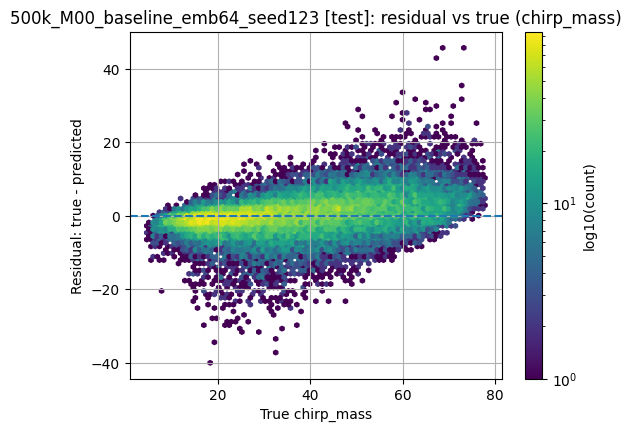

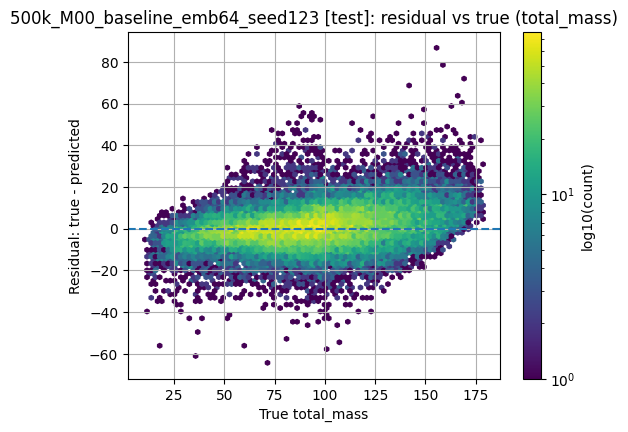

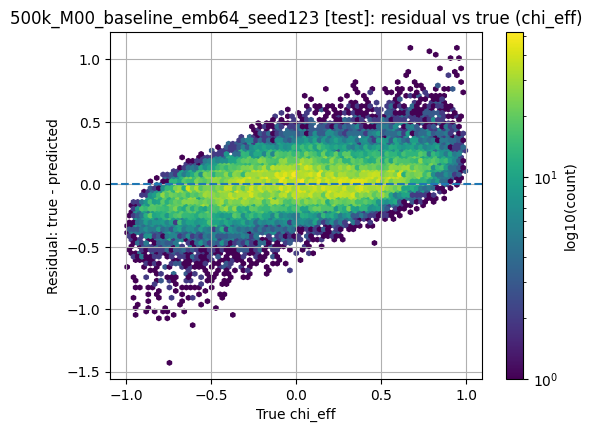

In [8]:
MODEL_ID = "500k_M00_baseline_emb64_seed123"
SPLIT = "test"

path = comparison_prediction_files[MODEL_ID]
data = np.load(path, allow_pickle=True)

pred = data[f"pred_{SPLIT}"]
y = data[f"y_{SPLIT}"]
y_mean = data["y_mean"]
y_std = data["y_std"]
label_names = get_label_names(data)

pred_phys = pred * y_std + y_mean
y_phys = y * y_std + y_mean
residual_phys = y_phys - pred_phys

for j, label in enumerate(label_names):
    plt.figure(figsize=(6, 4.5))
    hb = plt.hexbin(
        y_phys[:, j],
        residual_phys[:, j],
        gridsize=80,
        mincnt=1,
        bins="log",
    )
    plt.colorbar(hb, label="log10(count)")
    plt.axhline(0.0, linestyle="--")
    plt.xlabel(f"True {label}")
    plt.ylabel("Residual: true - predicted")
    plt.title(f"{MODEL_ID} [{SPLIT}]: residual vs true ({label})")
    plt.grid(True)
    plt.show()

## Error distributions (100k vs 500k)

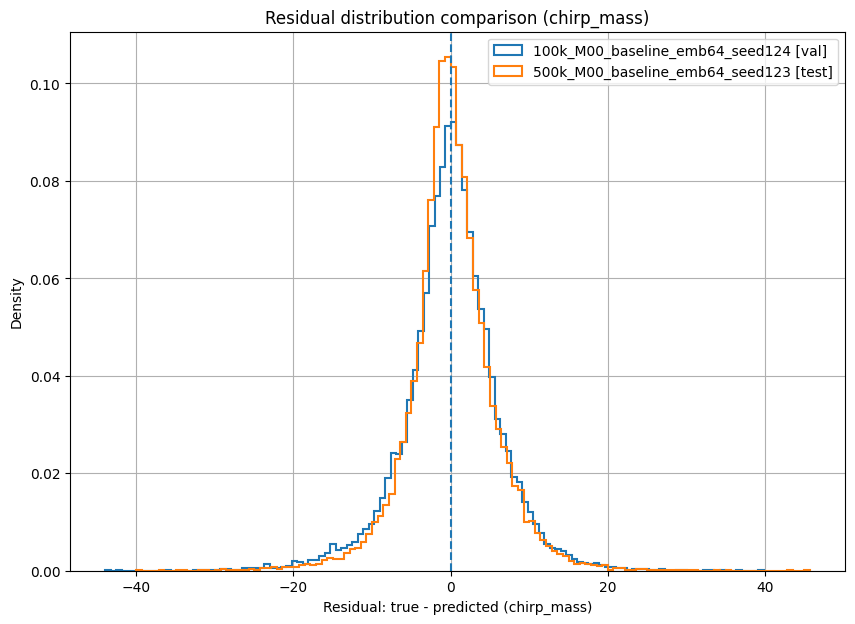

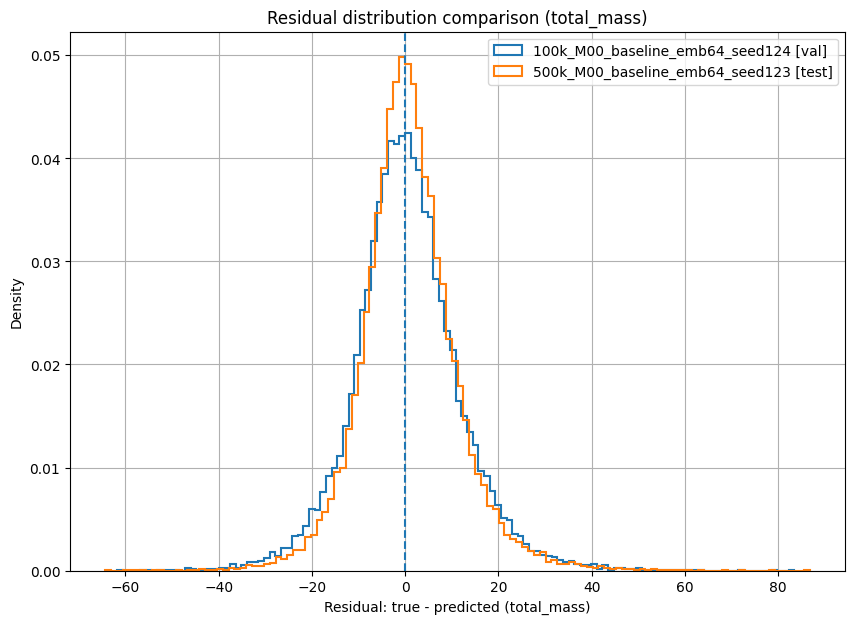

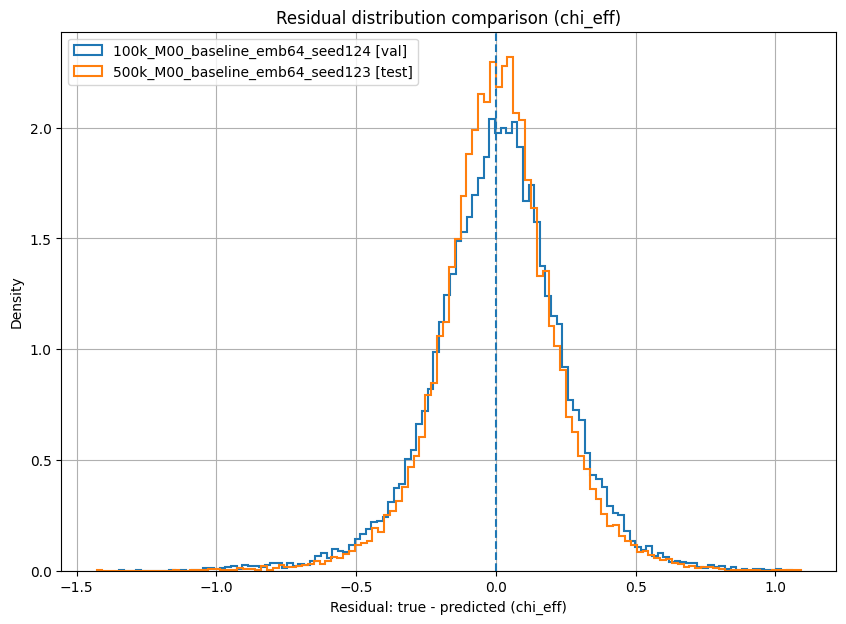

In [11]:
models_to_compare = [
    ("100k_M00_baseline_emb64_seed124", "val"),
    ("500k_M00_baseline_emb64_seed123", "test"),
]

for label_idx, label in enumerate(["chirp_mass", "total_mass", "chi_eff"]):
    plt.figure(figsize=(10, 7))

    for model_id, split in models_to_compare:
        path = comparison_prediction_files[model_id]
        data = np.load(path, allow_pickle=True)

        pred = data[f"pred_{split}"]
        y = data[f"y_{split}"]
        y_mean = data["y_mean"]
        y_std = data["y_std"]

        pred_phys = pred * y_std + y_mean
        y_phys = y * y_std + y_mean

        residual = y_phys[:, label_idx] - pred_phys[:, label_idx]

        plt.hist(
            residual,
            bins=120,
            density=True,
            histtype="step",
            linewidth=1.5,
            label=f"{model_id} [{split}]",
        )

    plt.axvline(0.0, linestyle="--")
    plt.xlabel(f"Residual: true - predicted ({label})")
    plt.ylabel("Density")
    plt.title(f"Residual distribution comparison ({label})")
    plt.legend(loc=0)
    plt.grid(True)
    plt.show()